# 04 Model Interpretation

目标：读取脚本训练后的评估、预测分数和 SHAP 输出，形成项目报告中可解释性与策略分析所需的结果展示。本 Notebook 不重新训练模型。

## 数据使用边界

- `train.py` 使用 Train 拟合预处理、特征筛选和模型；XGBoost 使用 Valid 做 early stopping。
- 分类阈值来自 Valid 上的 F1 最优点，方案比较和业务取舍也应优先参考 Valid 与业务目标。
- Test 是按时间留出的最终评估集，不参与训练、特征筛选、阈值选择或调参；本 Notebook 展示的 Test 指标只用于结果固定后的泛化检验。
- `score` 是风险排序分，不是校准后的欺诈概率。若要用于线上概率口径，需要后续做概率校准和线上回测。


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from IPython.display import Image, display

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

outputs = PROJECT_ROOT / "outputs"
experiment = "iv_002_050"


## 模型指标对比

下面先展示主解释方案 `iv_002_050` 的 Train、Valid、Test 指标，再展示 XGBoost 在各特征方案上的 Valid/Test 对比。主方案的定位是召回优先和解释优先，不代表所有测试指标都最高。


In [2]:
metrics_path = outputs / "tables/all_metrics_train_valid_test.csv"
if metrics_path.exists():
    metrics = pd.read_csv(metrics_path)
    main_metrics = metrics[metrics["Scheme"] == experiment].copy()
    display(main_metrics)

    xgb_compare = metrics[
        (metrics["Model"] == "xgboost")
        & (metrics["Split"].isin(["Valid", "Test"]))
    ][["Scheme", "Split", "AUC", "PR_AUC", "Precision", "Recall", "F1", "KS", "Threshold"]].copy()
    xgb_compare["Split"] = pd.Categorical(xgb_compare["Split"], ["Valid", "Test"], ordered=True)
    display(xgb_compare.sort_values(["Split", "AUC"], ascending=[True, False]))
else:
    print("No metrics found. Run scripts/train.py first.")


,AUC,PR_AUC,Precision,Recall,F1,KS,Threshold,Scheme,Model,Split
9,0.854060,0.355185,0.421862,0.352800,0.384252,0.553796,0.877853,iv_002_050,woe_lr,Train
10,0.817956,0.327212,0.474506,0.299803,0.367446,0.493714,0.877853,iv_002_050,woe_lr,Valid
11,0.827945,0.289602,0.398911,0.332793,0.362865,0.507353,0.877853,iv_002_050,woe_lr,Test
12,0.877920,0.492735,0.500076,0.454327,0.476105,0.593269,0.734682,iv_002_050,random_forest,Train
13,0.856978,0.411463,0.492401,0.372781,0.424322,0.543684,0.734682,iv_002_050,random_forest,Valid
14,0.858872,0.434209,0.446416,0.408044,0.426368,0.546993,0.734682,iv_002_050,random_forest,Test
15,0.964465,0.730933,0.670229,0.672995,0.671609,0.792491,0.795012,iv_002_050,xgboost,Train
16,0.914573,0.541694,0.566474,0.483235,0.521554,0.666744,0.795012,iv_002_050,xgboost,Valid
17,0.898320,0.506422,0.507381,0.479403,0.492995,0.644110,0.795012,iv_002_050,xgboost,Test


,Scheme,Split,AUC,PR_AUC,Precision,Recall,F1,KS,Threshold
7,iv_ge_002,Valid,0.915380,0.543759,0.598995,0.470414,0.526975,0.664981,0.814250
34,all_features,Valid,0.914806,0.544744,0.610310,0.459237,0.524104,0.667601,0.820211
16,iv_002_050,Valid,0.914573,0.541694,0.566474,0.483235,0.521554,0.666744,0.795012
25,iv_010_050,Valid,0.903699,0.519622,0.535636,0.479290,0.505899,0.642612,0.774204
35,all_features,Test,0.900841,0.515794,0.566502,0.447616,0.500091,0.645918,0.820211
8,iv_ge_002,Test,0.900307,0.510024,0.541195,0.449562,0.491141,0.642992,0.814250
17,iv_002_050,Test,0.898320,0.506422,0.507381,0.479403,0.492995,0.644110,0.795012
26,iv_010_050,Test,0.888536,0.489599,0.492308,0.467078,0.479361,0.619227,0.774204


## Top-K 风险排序

Top-K 表示按照 `score` 从高到低截取最高风险的一部分交易。它更适合人工审核资源有限的风控场景。不同审核容量下，最优方案可能不同：极小队列更看重 Precision，覆盖扩大后更看重欺诈捕获率。


In [3]:
topk_path = outputs / "tables/all_topk_train_valid_test_with_lift.csv"
if topk_path.exists():
    topk = pd.read_csv(topk_path)
    xgb_test_topk = topk[
        (topk["Model"] == "xgboost")
        & (topk["Split"] == "Test")
    ][["Scheme", "TopRate", "Precision", "RecallCapture", "Lift"]].copy()
    display(xgb_test_topk.sort_values(["TopRate", "RecallCapture"], ascending=[True, False]))

    main_topk = topk[
        (topk["Scheme"] == experiment)
        & (topk["Model"] == "xgboost")
        & (topk["Split"] == "Test")
    ].copy()
    display(main_topk)
else:
    print("No TopK table found. Run scripts/train.py first.")


,Scheme,TopRate,Precision,RecallCapture,Lift
140,all_features,0.01,0.883616,0.253649,25.388120
68,iv_002_050,0.01,0.876836,0.251703,25.193326
32,iv_ge_002,0.01,0.873446,0.250730,25.095929
104,iv_010_050,0.01,0.861017,0.247162,24.738807
141,all_features,0.03,0.534061,0.460266,15.344682
69,iv_002_050,0.03,0.532179,0.458644,15.290613
33,iv_ge_002,0.03,0.529168,0.456049,15.204104
105,iv_010_050,0.03,0.522394,0.450211,15.009456
34,iv_ge_002,0.05,0.384285,0.552060,11.041318
142,all_features,0.05,0.384060,0.551735,11.034831


,TopRate,TopN,Precision,RecallCapture,Lift,Scheme,Model,Split
68,0.01,885,0.876836,0.251703,25.193326,iv_002_050,xgboost,Test
69,0.03,2657,0.532179,0.458644,15.290613,iv_002_050,xgboost,Test
70,0.05,4429,0.379995,0.545897,10.918060,iv_002_050,xgboost,Test
71,0.10,8858,0.241590,0.694129,6.941369,iv_002_050,xgboost,Test


## SHAP 特征解释

SHAP 用于解释 XGBoost 在主方案中的主要风险信号来源。特征重要性图按风险特征类别着色，风险机制图按风险归因机制汇总，便于把模型结果转化为业务叙述。


In [4]:
shap_path = outputs / experiment / "shap/shap_importance.csv"
if shap_path.exists():
    shap_imp = pd.read_csv(shap_path)
    display(shap_imp.head(30))
else:
    print("No SHAP table found. Run scripts/explain.py first.")


,Feature,MeanSHAP,MeanAbsSHAP,MedianSHAP,PositiveSHAPRate,NegativeSHAPRate,SHAPShare,BaseFeature,FeatureCategory,RiskMechanism,FeatureType
0,C13,-0.272804,0.459095,-0.191199,0.3308,0.6692,0.079176,C13,行为计数统计特征,批量聚集与实体关联异常,numeric
1,C1,-0.042129,0.243508,-0.155087,0.2274,0.7726,0.041996,C1,行为计数统计特征,批量聚集与实体关联异常,numeric
2,TransactionAmt_log,-0.074965,0.241479,-0.117417,0.2976,0.7024,0.041646,TransactionAmt_log,交易基础特征,交易场景异常,numeric
3,C5,-0.094090,0.216125,0.081459,0.6246,0.3754,0.037273,C5,行为计数统计特征,批量聚集与实体关联异常,numeric
4,card6,-0.060777,0.206173,-0.162062,0.2430,0.7570,0.035557,card6,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
5,P_emaildomain,-0.024476,0.157068,0.055478,0.6436,0.3564,0.027088,P_emaildomain,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
6,card1,-0.072318,0.150474,-0.052958,0.3680,0.6320,0.025951,card1,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
7,V70,-0.057650,0.149952,0.062936,0.6578,0.3422,0.025861,V70,Vesta聚合统计特征,批量聚集与实体关联异常,numeric
8,card2,-0.058080,0.145911,-0.029058,0.4286,0.5714,0.025164,card2,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
9,M4,-0.039446,0.142084,-0.103907,0.4456,0.5544,0.024504,M4,身份匹配一致性特征,身份一致性异常,categorical_encoded


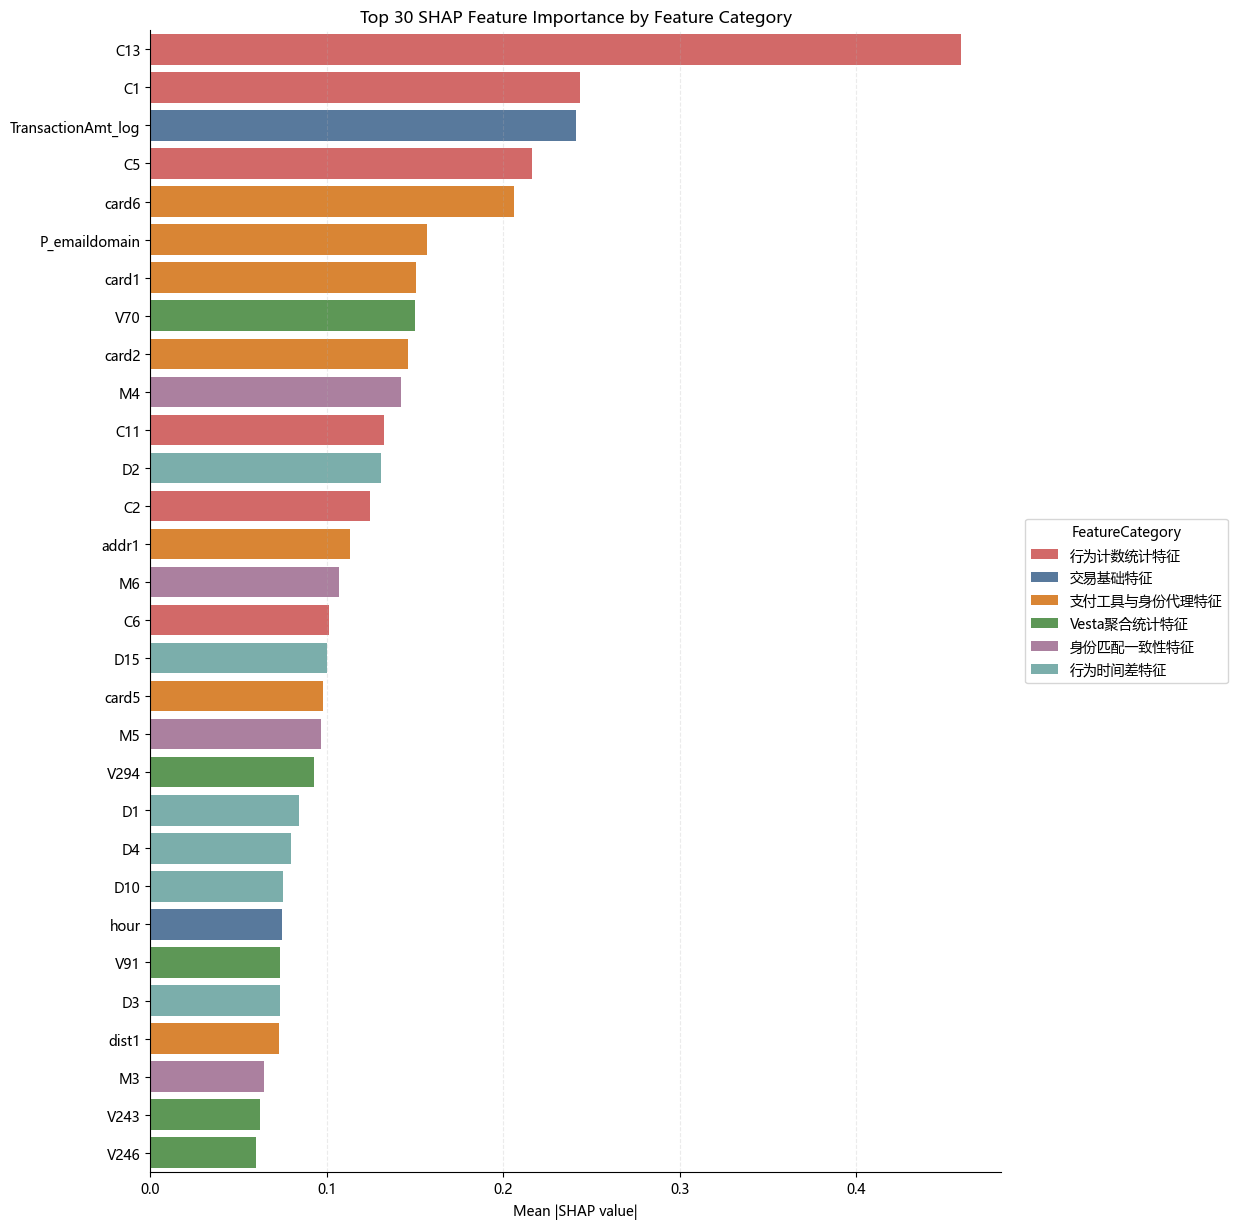

Saved: D:\Vs code\ieee-fraud-project\outputs\iv_002_050\shap\shap_importance_top30_by_category.png
Synced README assets to: D:\Vs code\ieee-fraud-project\docs\assets


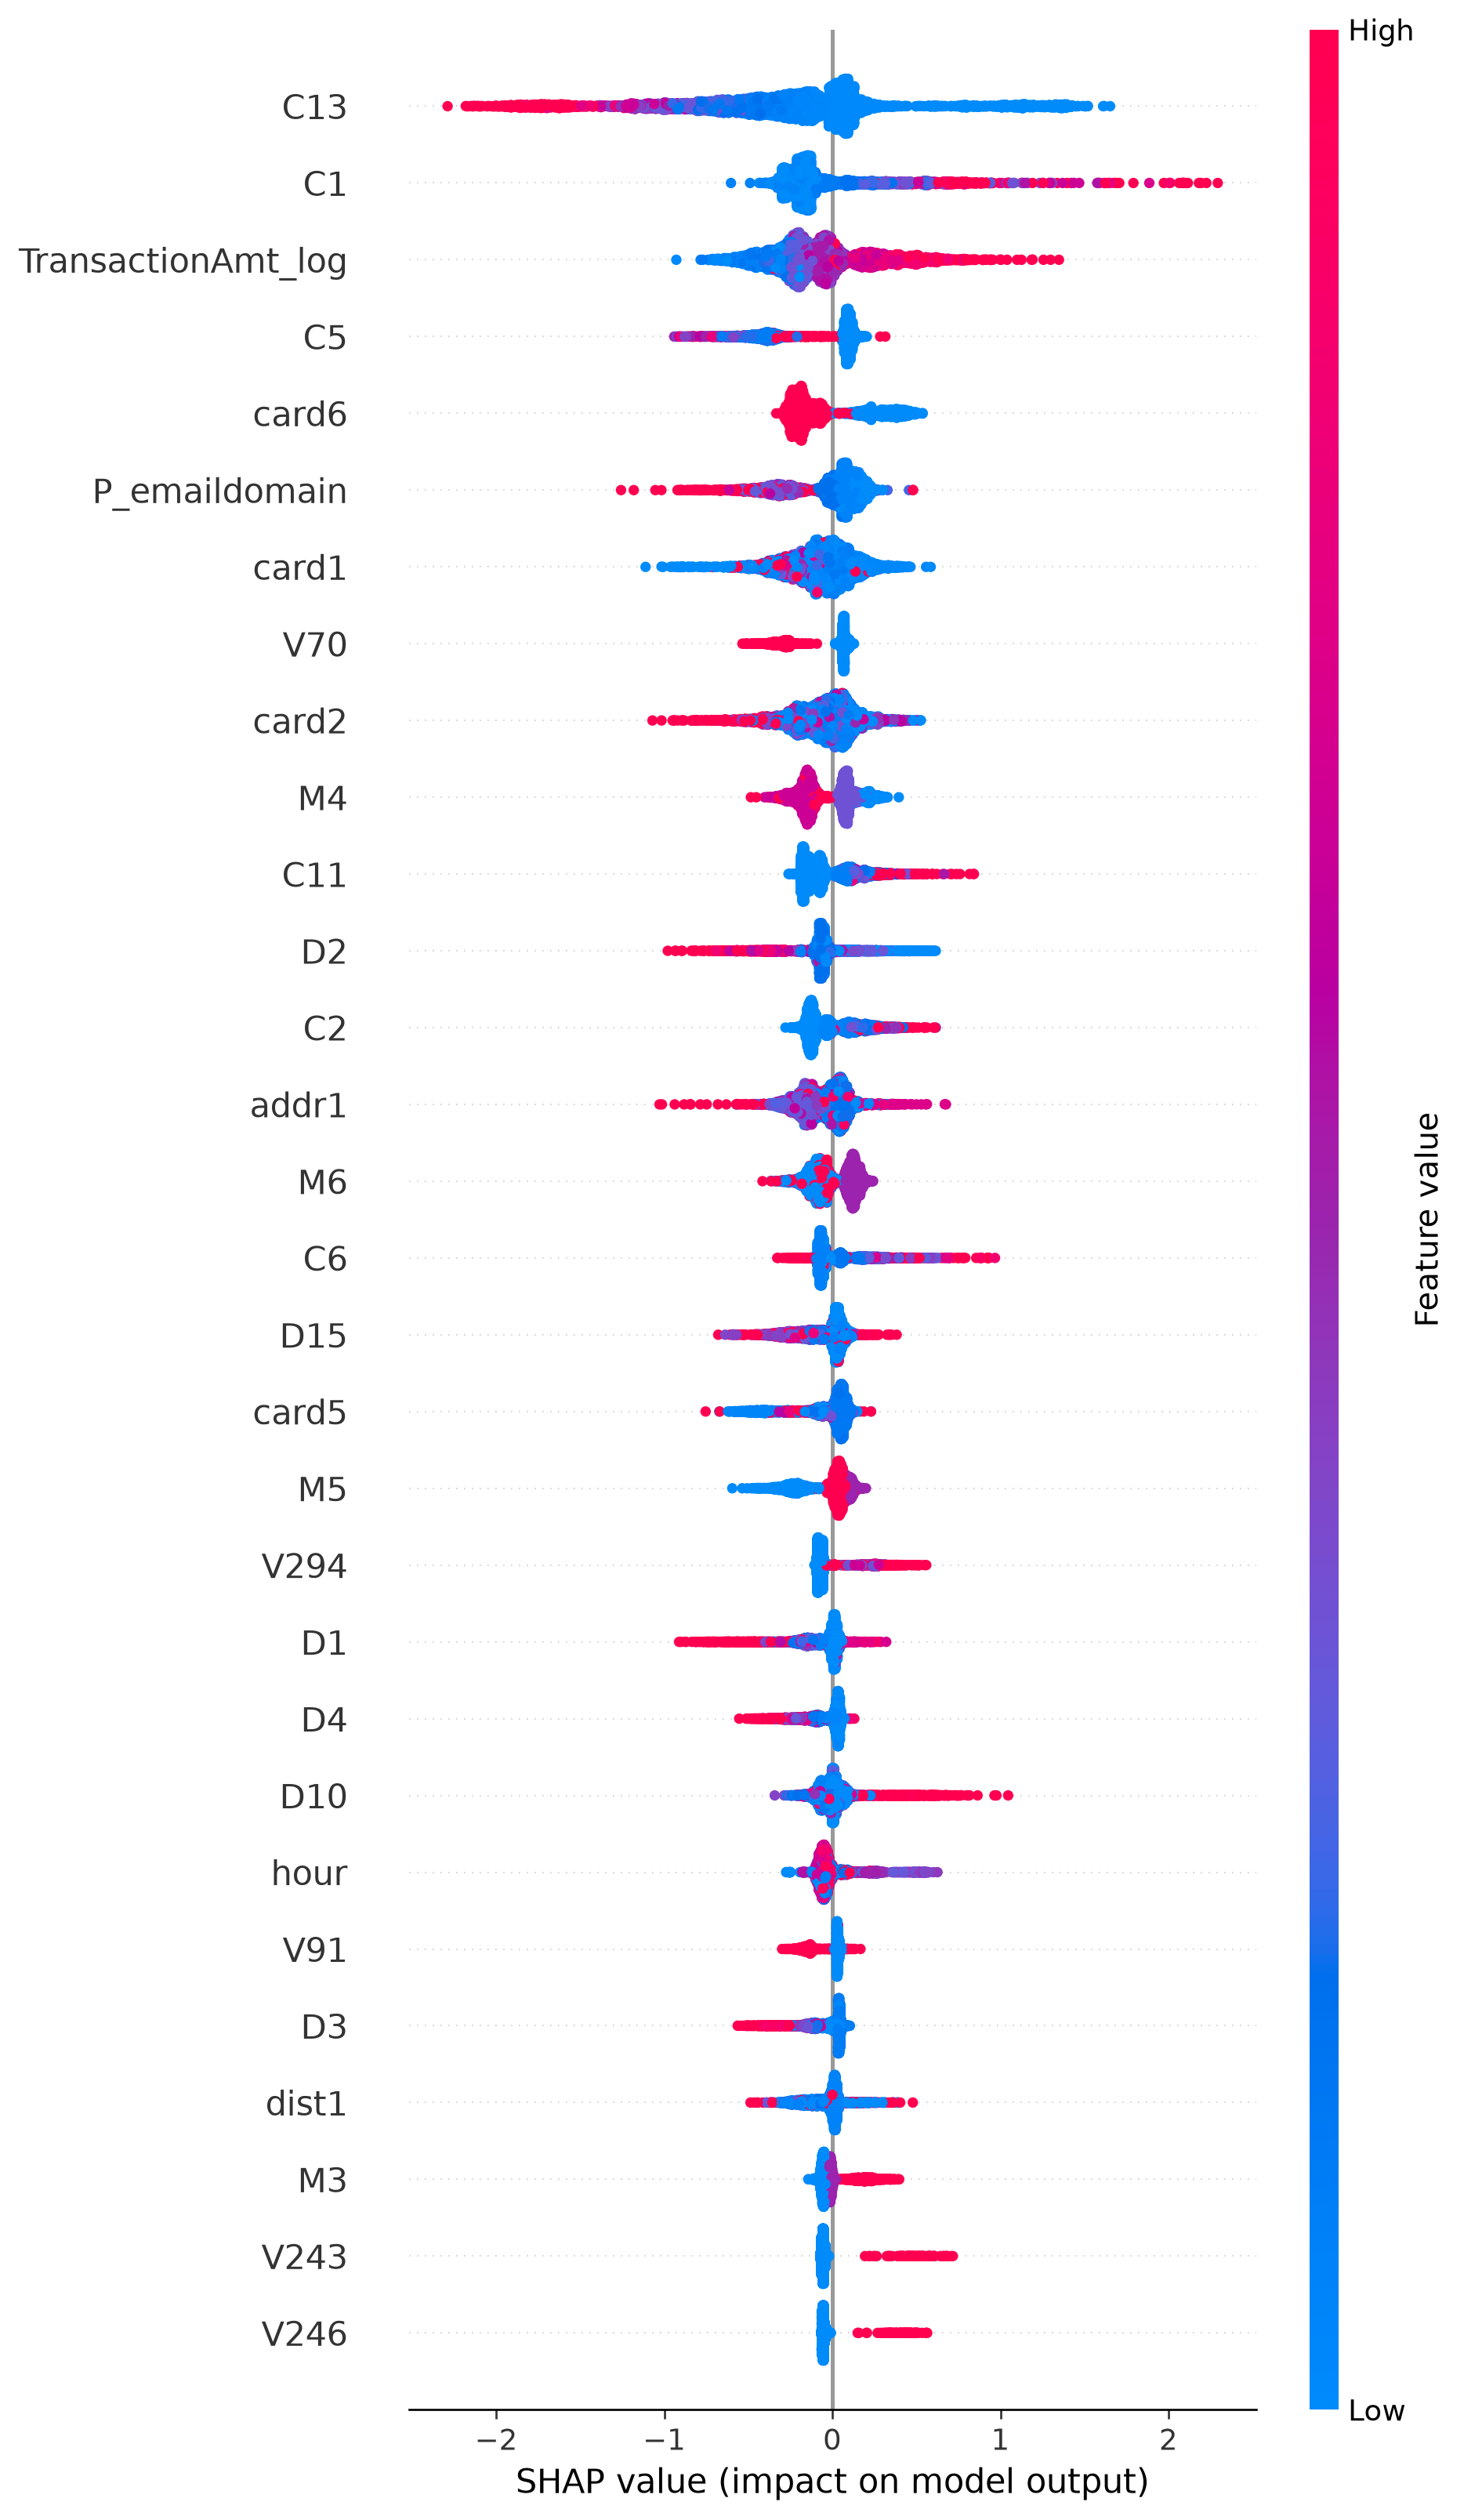

In [5]:
shap_path = outputs / experiment / "shap/shap_importance.csv"
summary_fig_path = outputs / experiment / "shap/shap_summary_top30.png"
colored_fig_path = outputs / experiment / "shap/shap_importance_top30_by_category.png"

category_palette = {
    "交易基础特征": "#4C78A8",
    "支付工具与身份代理特征": "#F58518",
    "行为计数统计特征": "#E45756",
    "行为时间差特征": "#72B7B2",
    "身份匹配一致性特征": "#B279A2",
    "Vesta聚合统计特征": "#54A24B",
    "设备网络与数字指纹特征": "#FF9DA6",
    "未分类": "#9D9D9D",
}

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

if shap_path.exists():
    shap_imp = pd.read_csv(shap_path).head(30).copy()
    shap_imp["FeatureCategory"] = shap_imp["FeatureCategory"].fillna("未分类")
    plot_df = shap_imp.sort_values("MeanAbsSHAP", ascending=False)

    fig_height = max(7, 0.36 * len(plot_df) + 1.6)
    fig, ax = plt.subplots(figsize=(12.5, fig_height))
    sns.barplot(
        data=plot_df,
        x="MeanAbsSHAP",
        y="Feature",
        hue="FeatureCategory",
        dodge=False,
        palette=category_palette,
        ax=ax,
    )
    ax.set_title("Top 30 SHAP Feature Importance by Feature Category")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.legend(title="FeatureCategory", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    sns.despine(ax=ax)
    plt.tight_layout()
    fig.savefig(colored_fig_path, dpi=180, bbox_inches="tight")
    docs_assets = PROJECT_ROOT / "docs/assets"
    docs_assets.mkdir(parents=True, exist_ok=True)
    shutil.copy2(colored_fig_path, docs_assets / colored_fig_path.name)
    if summary_fig_path.exists():
        shutil.copy2(summary_fig_path, docs_assets / summary_fig_path.name)
    plt.show()
    print(f"Saved: {colored_fig_path}")
    print(f"Synced README assets to: {docs_assets}")
else:
    print("No SHAP table found. Run scripts/explain.py first.")

if summary_fig_path.exists():
    display(Image(filename=str(summary_fig_path)))
else:
    print(f"Missing: {summary_fig_path}")


## 风险机制归因

该图把单个特征的平均绝对 SHAP 值汇总到风险机制层面。它回答的是“模型主要依赖哪些风险归因机制”，不是因果结论。


,RiskMechanism,FeatureCount,TotalMeanAbsSHAP,AvgMeanAbsSHAP,AvgMeanSHAP,AvgPositiveSHAPRate,SHAPShare
0,批量聚集与实体关联异常,224,2.956137,0.013197,-0.004364,0.458137,0.509818
1,支付身份与联系方式异常,10,1.046782,0.104678,-0.037316,0.433380,0.180529
2,行为时序节奏异常,15,0.704329,0.046955,-0.021526,0.479293,0.121469
3,身份一致性异常,9,0.455276,0.050586,-0.007480,0.378778,0.078517
4,设备网络与数字指纹异常,25,0.320007,0.012800,-0.003066,0.365200,0.055189
5,交易场景异常,2,0.315882,0.157941,-0.042940,0.253100,0.054477


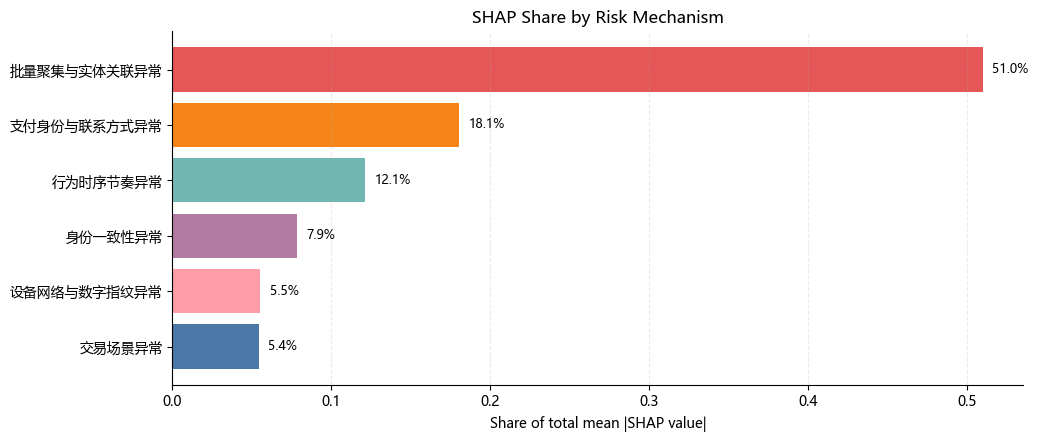

Saved: D:\Vs code\ieee-fraud-project\outputs\iv_002_050\shap\risk_mechanism_shap_share.png


In [6]:
mechanism_path = outputs / experiment / "shap/shap_mechanism_summary.csv"
mechanism_fig_path = outputs / experiment / "shap/risk_mechanism_shap_share.png"
mechanism_palette = {
    "交易场景异常": "#4C78A8",
    "支付身份与联系方式异常": "#F58518",
    "批量聚集与实体关联异常": "#E45756",
    "行为时序节奏异常": "#72B7B2",
    "身份一致性异常": "#B279A2",
    "设备网络与数字指纹异常": "#FF9DA6",
    "未分类": "#9D9D9D",
}

if mechanism_path.exists():
    mechanism = pd.read_csv(mechanism_path).sort_values("SHAPShare", ascending=False)
    display(mechanism)

    fig_height = max(4.5, 0.52 * len(mechanism) + 1.4)
    fig, ax = plt.subplots(figsize=(10.5, fig_height))
    colors = [mechanism_palette.get(x, "#9D9D9D") for x in mechanism["RiskMechanism"]]
    ax.barh(mechanism["RiskMechanism"], mechanism["SHAPShare"], color=colors)
    ax.invert_yaxis()
    ax.set_title("SHAP Share by Risk Mechanism")
    ax.set_xlabel("Share of total mean |SHAP value|")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    for i, value in enumerate(mechanism["SHAPShare"]):
        ax.text(value + 0.006, i, f"{value:.1%}", va="center", fontsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    fig.savefig(mechanism_fig_path, dpi=180, bbox_inches="tight")

    docs_assets = PROJECT_ROOT / "docs/assets"
    docs_assets.mkdir(parents=True, exist_ok=True)
    shutil.copy2(mechanism_fig_path, docs_assets / mechanism_fig_path.name)
    plt.show()
    print(f"Saved: {mechanism_fig_path}")
else:
    print("No risk mechanism summary found. Run scripts/explain.py first.")
